In [44]:
#import user modules
#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

import sys
my_path = "../../Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

from fit_funcs import *
import costfun.costfun as cost
import utils.figures as fig_help
import utils.tools as tools
from RandomMatrixTheory import goe
from fermion_tools import *
import entropy as ent

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)

import itertools
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}

%matplotlib inline
colors_ls = (list(mcolors.TABLEAU_COLORS)[:200])
colors_ls_cyc = itertools.cycle(colors_ls)

markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   


# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import erf
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import gamma as gamma_fun
from scipy.special import digamma
from scipy.special import lambertw
from scipy.special import voigt_profile
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
from scipy.interpolate import UnivariateSpline as InterpolateSpline
from scipy.interpolate import make_interp_spline as make_spline
from scipy.interpolate import splrep, splev
from mpl_toolkits.axes_grid1 import make_axes_locatable
 
# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists

BOUNDARY_COND = 'PBC'
base_dir = "../results/" + BOUNDARY_COND + '/'

%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}

/Users/rafal.swietek/Projects/CODES/QHamSolver/Fermions/Jupyter_Python
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../Python/


In [45]:
def NonGaussianity(x, n=4, ens=1):
    y = 0
    if ens:
        for k in range(1, n+1):
            val = gamma_fun(2*k - 1) / gamma_fun(k + 1)
            for s in range(k, 2*k):
                # print(k, s)
                val = val / (s + x)
            y += val
        return 1 - y / np.log(2)
    else:
        y = 3 / 2 / (x + 2)
        if n > 1: y += 3/12 * (9*x + 26) / ( (x+2)*(x+4)*(x+6) )
        if n > 2: y += 135/30 * (3*x**2 + 26*x + 48) / ( (x+2)*(x+4)*(x+6)*(x+8)*(x+10) )
        if n > 3: y += 9/56 * (945*x**3 + 1701*x**2+11705*x+210874) / ( (x+2)*(x+4)*(x+6)*(x+8)*(x+10)*(x+12)*(x+14) )
        return 1 - y / np.log(2)


In [46]:

def FF_terms(f, x, n):
    if n == 1:  return 2/(1+x) * f
    if n == 2:  return (8/3 * f**2 - 3*f**3) * 4*(5+x) / ( (1+x)*(2+x)*(3+x) ) + 12/( (2+x)*(3+x) ) * f**3
    if n == 3:  return ( (11*f**3 - 36*f**4 + 30*f**5) * 8*(x**2 + 15*x + 74) + (12*f**4 - 15*f**5) * 24*(x + 14)*(x + 1) + f**5 * 120*(x+1)*(x+2)) / ( (1+x)*(2+x)*(3+x)*(4+x)*(5+x) )
    if n == 4:  
        res = 908/15  * 16*(x**3 + 30*x**2 + 371*x + 2118)    / ( (1+x)*(2+x)*(3+x)*(4+x)*(5+x)*(x+6)*(x+7) ) * f**4\
                    -   1296/5  * 24*(x + 9)                            / ( (1+x)*(3+x)*(4+x)*(5+x) )                   * f**5\
                    +   5816/63 * 144*(x**3 + 22*x**2 + 123*x + 134)    / ( (1+x)*(2+x)*(3+x)*(4+x)*(5+x)*(x+6)*(x+7) ) * f**6\
                    +   1024/3  * 240*(x + 13)                          / ( (1+x)*(4+x)*(5+x)*(x+6)*(x+7) )             * f**6\
                    -   272     * 1680                                  / ( (4+x)*(5+x)*(x+6)*(x+7) )                   * f**7
        if f >= 1/4 and f < 1/3:    res += (8192/315*f**6 - 2048/45*f**5 + 512/15*f**4 - 128/9*f**3 + 32/9*f**2 - 8/15*f + 2/45 - 1/(630*f)) * 144*(x**3 + 22*x**2 + 123*x + 134)   / ( (1+x)*(2+x)*(3+x)*(4+x)*(5+x)*(x+6)*(x+7) ) 
        if f >= 1/3 and f <= 1/2:   res += (12136/63*f**6 - 13712/45*f**5 + 556/3*f**4 - 452/9*f**3 + 32/9*f**2 + 16/15*f - 2/9 + 1/(90*f)) * 144*(x**3 + 22*x**2 + 123*x + 134)    / ( (1+x)*(2+x)*(3+x)*(4+x)*(5+x)*(x+6)*(x+7) )
        return res
    else:       return 0

def correction(n=4):
    return np.log(2) - np.sum( [1 / (2 * k * (2 * k - 1)) for k in range(1, n)] )

def leading_FF_terms(f, x, n=4):

    res = FF_terms(f=f, x=x, n=1) / 2
    if n >= 2:  res += FF_terms(f=f, x=x, n=2) / 12
    if n >= 3:  res += FF_terms(f=f, x=x, n=3) / 30
    if n >= 4:  res += FF_terms(f=f, x=x, n=4) / 56
    return res

def FF_upper_bound(f, x, n):
    return 1 - leading_FF_terms(f, x, n=n) / (np.log(2))

def FF_lower_bound(f, x, n):
    return 1 - (leading_FF_terms(f=f, x=x, n=n) + FF_terms(f=f, x=x, n=n) * correction(n=n+1)) / (np.log(2))


[3432] 3432.0
[11250] 12870.0
[48620] 48620.0
[166252] 184756.0
[705432] 705432.0
[2478716] 2704156.0
[10400600] 10400600.0


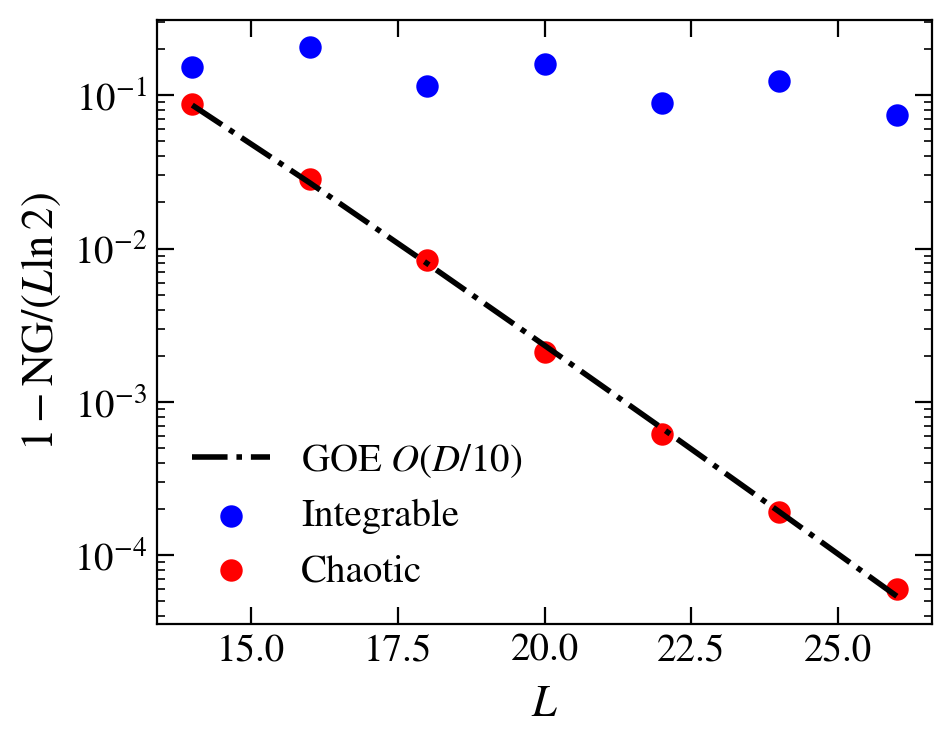

In [7]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,4), dpi = 200, sharey=True)

nx = 1/2

for iin, n in enumerate( [nx] ):
    f = 1
    sizes = np.arange(14, 27, 2) if n == 1/2 else np.arange(15, 29, 3)


    NonGauss_int = np.zeros(sizes.shape)
    NonGauss_ch = np.zeros(sizes.shape)
    dims = np.zeros(sizes.shape)
    for iiL, L in enumerate(sizes):
        subsystem = np.arange(0, L, 1)
        N = int(L * n)
        
        real_sec, imag_sec = get_sectors(L, BOUNDARY_COND, mu)
        
        dim_tot = 0
        dim_tot2 = 0
        for [ks, ps, zxs] in real_sec+imag_sec:
        # for [ks, ps, zxs] in real_sec:
        # for [ks, ps, zxs] in [ [1,1,1] ]:
            factor = 1 if ks == 0 or ks == L / 2 else 2
            V1 = 1.1
            V2 = 0
            t2 = 0
            name = base_dir + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=mu, k=ks, p=ps, zx=zxs) + ".hdf5"
            if exists(name):
                with h5py.File(name, "r") as file:
                    Ex = np.array(file.get('energies')[0])
                    try:
                        dim = np.array(file.get('D')[0])
                    except TypeError:
                        dim = Ex.size
                    _, indices, counts = np.unique(np.round(Ex, 14), return_index=True, return_counts=True)
                    x = counts[counts > 1]
                    dims[iiL] = dim
                    if x.size > 0:
                        a=1
                        # print(L, ks, ps)
                    else:
                        NG = np.array(file.get('Non-Gaussianity')[0]) / (L * np.log(2))
                        NonGauss_int[iiL] += dim * factor * np.mean(NG)
                        dim_tot += factor * dim
            else:
                print(name)
            
            V1 = 0.55
            V2 = 2
            t2 = 2
            name = base_dir + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=mu, k=ks, p=ps, zx=zxs) + ".hdf5"
            if exists(name):
                with h5py.File(name, "r") as file:
                    Ex = np.array(file.get('energies')[0])
                    try:
                        dim = np.array(file.get('D')[0])
                    except TypeError:
                        dim = Ex.size
                    _, indices, counts = np.unique(np.round(Ex, 14), return_index=True, return_counts=True)
                    x = counts[counts > 1]
                    if x.size > 0:
                        a=1
                        # print(L, ks, ps)
                    else:
                        NG = np.array(file.get('Non-Gaussianity')[0]) / (L * np.log(2))
                        NonGauss_ch[iiL] += dim * factor * np.mean(NG)
                        # NonGauss_ch[iiL] += factor * np.mean(NG)
                        dim_tot2 += factor * dim
            else:
                print(name)
        NonGauss_int[iiL] /= dim_tot
        NonGauss_ch[iiL] /= dim_tot2
        print(dim_tot, binom(L, N))
    axis.scatter(sizes, 1 - NonGauss_int, s=50, label='Integrable', color='blue', marker='s' if iin else 'o', facecolor='None' if iin else 'blue')
    axis.scatter(sizes, 1 - NonGauss_ch,  s=50, label='Chaotic'   , color='red',  marker='s' if iin else 'o', facecolor='None' if iin else 'red')

# print(1 - NonGauss_ch)

# z = np.linspace(0.001, 0.1, 1000)
# z = np.linspace(min(sizes)-1, max(sizes)+1, 1000)
# axis.plot(z, 1-NonGaussianity(0.4/z, n=10, ens=1), ls='--', color='gray', lw=2)
# axis.plot(z, 1-NonGaussianity(1/3/z, n=20, ens=1), ls='--', color='gray', lw=2, label=r"GUE $O(L/2)$")
axis.plot(sizes, 1 - NonGaussianity( dims/10, n=4, ens=0), ls='-.', color='k', lw=2, label=r"GOE $O(D/10)$")
# axis.plot(sizes, 1 - NonGaussianity( dims/16, n=4, ens=1), ls='--', color='green', lw=2, label=r"GUE $O(D/16)$")
# axis.plot(z, 1-NonGaussianity(0.1 * 2**(1/z), n=2, ens=0), ls=':', color='red', lw=2)

# axis.axhline(y = 1-NonGaussianity(22, n=3, ens=0), ls='--', color='gray')
fig_help.set_plot_elements(axis, ylabel=r"$1-{\rm NG}/(L\ln{2})$", xlabel=r"$L$", font_size=14, set_legend=True, xscale='linear', yscale='log')
axis.set_ylim(0, None)

# print(0.08186246*9, 0.08186246*27, 0.08186246*11)

fig.savefig("plots_mixing/Fig3.pdf", bbox_inches = 'tight', pad_inches=0.02)

16 0 4 1
20 0 5 1
24 0 6 1


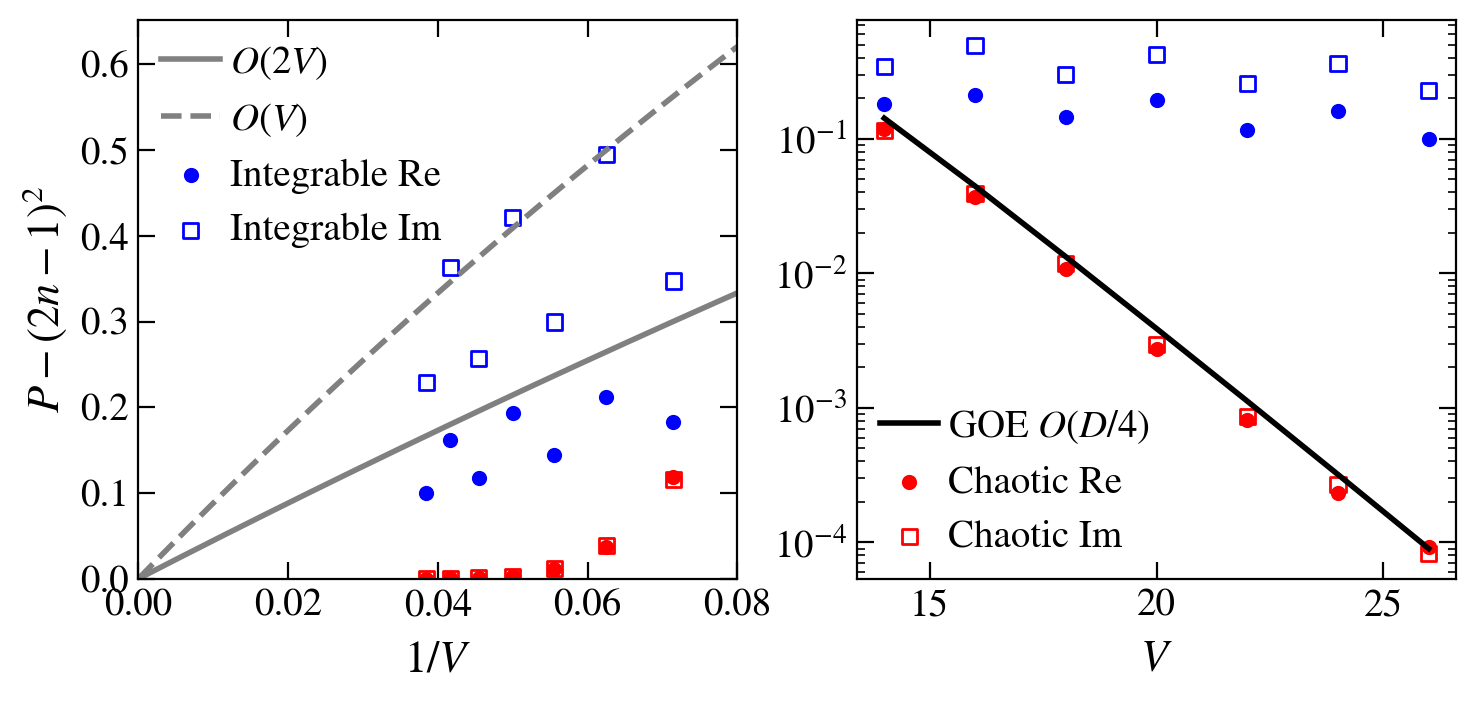

In [54]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(8.5,3.7), dpi = 200, sharex=False)

n = 1/2
f = 1
sizes = np.arange(14, 27, 2) if n == 1/2 else np.arange(15, 31, 3)

Purity_int_re = np.zeros(sizes.shape)
Purity_int_im = np.zeros(sizes.shape)
Purity_int_tot = np.zeros(sizes.shape)

Purity_ch_re = np.zeros(sizes.shape)
Purity_ch_im = np.zeros(sizes.shape)

Chaotic_GOE = np.zeros(sizes.shape)
Chaotic_GUE = np.zeros(sizes.shape)
dims = np.zeros(sizes.shape)
for iiL, L in enumerate(sizes):
    subsystem = np.arange(0, L, 1)
    N = int(n * L)
    LA = int(f * L) if f > 0 else 1
    idx = np.argmin( np.abs(subsystem - LA) )
    if LA == L: idx = -1
    real_sec, imag_sec = get_sectors(L, BOUNDARY_COND, mu)
    
    dim_tot = 0
    dim_tot_im = 0
    dim_tot_ch = 0
    dim_tot_ch_im = 0
    for [ks, ps, zxs] in real_sec + imag_sec:
    # for [ks, ps, zxs] in imag_sec:
    # for [ks, ps, zxs] in [[0, 1, 1], [1, 1, 1]]:
        # if ks == L / 4: print("Omitting k=\pi/2 sector"); continue;
    # for [ks, ps, zxs] in [[1, 1, 1]]:
        factor = 1 if ks == 0 or ks == L / 2 else 2
        # print(L, ks, ps, factor)
        V1 = 0.55
        V2 = 0
        t2 = 0
        
        name = base_dir + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=mu, k=ks, p=ps, zx=zxs) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                _, indices, counts = np.unique(np.round(Ex, 14), return_index=True, return_counts=True)
                x = counts[counts > 1]
                try:
                    dim = np.array(file.get('D')[0])
                except TypeError:
                    dim = Ex.size
                    
                if x.size > 0:
                    a=1
                    print(L, V2, ks, ps)#, x, Ex[indices[counts > 1]])
                else:
                    gaps = np.diff(Ex)
                    ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
                    # print(L, ks, ps, np.mean(ratio_tmp))
                    # dim = Ex.size
                    P = np.array(file.get('Purity')[idx, :]) / LA - (2 * n - 1)**2
                    
                    if factor == 1:
                        Purity_int_re[iiL] += dim * factor * np.mean(P)
                        # print(L, ks, ps, dim, np.mean(P))
                        dim_tot += factor * dim
                    else:
                        Purity_int_im[iiL] += dim * factor * np.mean(P)
                        dim_tot_im += factor * dim
                        
        else:
            print(name)
        V1=0.55
        V2 = 2
        t2 = 2
        name = base_dir + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=mu, k=ks, p=ps, zx=zxs) + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                Ex = np.array(file.get('energies')[0])
                _, indices, counts = np.unique(np.round(Ex, 14), return_index=True, return_counts=True)
                x = counts[counts > 1]
                
                try:
                    dim = np.array(file.get('D')[0])
                    # print(L, ks, ps, dim)
                except TypeError:
                    dim = Ex.size
                dims[iiL] = dim
                
                if x.size > 0:
                    a=1
                    print(L, V2, ks, ps, Ex[indices[counts > 1]])
                else:
                    gaps = np.diff(Ex)
                    ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
                    # print(L, ks, ps, np.mean(ratio_tmp))
                    # dim = Ex.size
                    P = np.array(file.get('Purity')[idx, :]) / LA - (2 * n - 1)**2
                    # axis[1].scatter(L, np.mean(P), marker='v', color='red', alpha=0.2)
                    
                    Chaotic_GOE[iiL] += dim * factor * 9 / (2 + dim/3)
                    if factor == 1:
                        Purity_ch_re[iiL] += dim * factor * np.mean(P)
                        dim_tot_ch += factor * dim
                    else:
                        Purity_ch_im[iiL] += dim * factor * np.mean(P)
                        Chaotic_GUE[iiL] += dim * factor
                        dim_tot_ch_im += factor * dim
        else:
            print(name)
    Purity_int_tot[iiL] = (Purity_int_re[iiL] + Purity_int_im[iiL]) / (dim_tot + dim_tot_im)
    
    if dim_tot > 0: Purity_int_re[iiL] /= dim_tot
    if dim_tot_im > 0: Purity_int_im[iiL] /= dim_tot_im
    if dim_tot_ch > 0: Purity_ch_re[iiL] /= dim_tot_ch
    if dim_tot_ch_im > 0: Purity_ch_im[iiL] /= dim_tot_ch_im
    # Purity_ch_tot[iiL] = (Purity_ch_re[iiL] + Purity_ch_im[iiL]) / (dim_tot + dim_tot_im)
    
    # Chaotic_GOE[iiL] /= (dim_tot_ch + dim_tot_ch_im)
    # Chaotic_GUE[iiL] /= dim_tot_ch_im
    # print(dim_tot, binom(L, N))
# axis[0].scatter(1/sizes, Purity_int_tot, s=20, label='Integrable', color='blue', marker='v')
# print(Purity_int_tot)
    
Chaotic_GOE = 9 / (2 + dims/4)
Chaotic_GUE = 4 / (1 + dims/4)

axis[0].scatter(1/sizes, Purity_int_re, s=20, label='Integrable Re', color='blue')
axis[1].scatter(sizes, Purity_int_re, s=20, color='blue')

axis[0].scatter(1/sizes, Purity_ch_re, s=20, color='red')
# axis[1].scatter(sizes, Purity_ch_re, s=20, label='Chaotic Re', color='red')
axis[1].scatter(sizes, Purity_ch_re, s=20, label='Chaotic Re', color='red')

axis[0].scatter(1/sizes, Purity_int_im, s=30, color = 'blue', marker='s', facecolor='None', label='Integrable Im')
axis[1].scatter(sizes, Purity_int_im, s=30, color = 'blue', marker='s', facecolor='None')

axis[0].scatter(1/sizes, Purity_ch_im, s=30, color = 'red', marker='s', facecolor='None')
# axis[1].scatter(sizes, Purity_ch_im, s=30, color = 'red', marker='s', facecolor='None', label='Chaotic Im')
axis[1].scatter(sizes, Purity_ch_im, s=30, color = 'red', marker='s', facecolor='None', label='Chaotic Im')

z = np.linspace(0, 0.08, 1000)
axis[0].plot(z, 9 / (2 + 2/z), ls='-', lw=2, color='gray', label=r"$O(2V)$")
# axis[0].plot(z, 4 / (1 + 1/z), ls='-.', lw=2, color='pink', label=r"GUE $O(V)$")
axis[0].plot(z, 9 / (2 + 1/z), ls='--', lw=2, color='gray', label=r"$O(V)$")
# axis[0].plot(z, 4 / (1 + 1/3/z), ls='-.', lw=2, color='pink', label=r"GUE $O(V/3)$")
# axis[0].plot(z, 4 / (1 + 1/3/z), ls='-.', lw=2, color='pink', label=r"GUE $O(V)$")
# def fit_purity(x: float, a: int, b: int):
#     return 9 / (2 + b * x)

# pars, pconv, fit_info, msg, _ = fit(fit_purity,
#                         xdata = sizes[1:],
#                         ydata = Purity_int_im[1:],
#                         full_output=True, maxfev=10000)
# print("Imag", *pars)
# xx = np.linspace(0, max(1/sizes), 10000)
# axis[0].plot( xx, fit_purity(1/xx, *pars), ls='-',  color = 'blue')


# pars, pconv, fit_info, msg, _ = fit(fit_purity,
#                         xdata = sizes[1:],
#                         ydata = Purity_int_re[1:],
#                         full_output=True, maxfev=10000)
# print("Real", *pars)
# axis[0].plot( xx, fit_purity(1/xx, *pars), ls='-.',  color = 'blue')

# xx = np.linspace(dims[0]/2, dims[-1]*2, 10000)
# pars, pconv, fit_info, msg, _ = fit(fit_purity,
#                         xdata = 2**sizes[1:],
#                         ydata = Purity_ch_re[1:],
#                         full_output=True, maxfev=10000)
# print(*pars)
# xx = np.linspace(min(sizes)-1, max(sizes)+1, 10000)
# axis[1].plot(xx, fit_purity(2**xx, *pars), ls='-',  color = 'red')

axis[1].plot(sizes, Chaotic_GOE, ls='-', lw=2, color='k', label=r"GOE $O(D/4)$")
# axis[1].plot(sizes, Chaotic_GUE, ls=':',  lw=2, color='green', label=r"GUE $O(D/4)$")

fig_help.set_plot_elements(axis[0], ylabel=r"$P-(2n-1)^2$", xlabel=r"$1/V$", font_size=14, set_legend=True, xlim=(0, 0.08), xscale='linear', yscale='linear')
fig_help.set_legend(axis[0], fontsize=14, loc = 'upper left', ncol=1, columnspacing=0.4, frameon=False, anchor=(-0.02, 1.02))
fig_help.set_plot_elements(axis[1], ylabel=r"", xlabel=r"$V$", font_size=14, set_legend=True, xscale='linear', yscale='log')
fig_help.set_legend(axis[1], fontsize=14, loc = 'lower left', ncol=1, columnspacing=0.4, frameon=False, anchor=(-0.02, -0.02))
axis[0].set_ylim(0, None)
fig.savefig("plots_mixing/Fig2.pdf", bbox_inches = 'tight', pad_inches=0.02)

14 113
14 133
14 133
14 113
14 245
14 245
14 245
14 245
14 245
14 245
18 1317
18 1387
18 1387
18 1317
18 2700
18 2700
18 2703
18 2700
18 2700
18 2703
18 2700
18 2700
22 15907
22 16159
22 16159
22 15907
22 32065
22 32065
22 32065
22 32065
22 32065
22 32065
22 32065
22 32065
22 32065
22 32065
26 500
26 500
26 500
26 500
26 500
26 500
26 500
26 500
26 500
26 500
26 500
26 500
26 500
26 500
26 500
26 500
15 90
15 111
15 200
15 200
15 200
15 200
15 201
15 200
15 200
18 486
18 542
18 505
18 533
18 1035
18 1026
18 1038
18 1026
18 1035
18 1028
18 1035
18 1026
21 2709
21 2829
21 5537
21 5537
21 5537
21 5537
21 5537
21 5537
21 5538
21 5537
21 5537
21 5537
24 15168
24 15498
24 15251
24 15416
24 30624
24 30664
24 30624
24 30667
24 30624
Omitting k=\pi/2 sector
24 30624
24 30666
24 30624
24 30664
24 30624
27 500
27 500
27 500
27 500
27 500
27 500
27 500
27 500
27 500
27 500
27 500
27 500
27 500
27 500
27 500


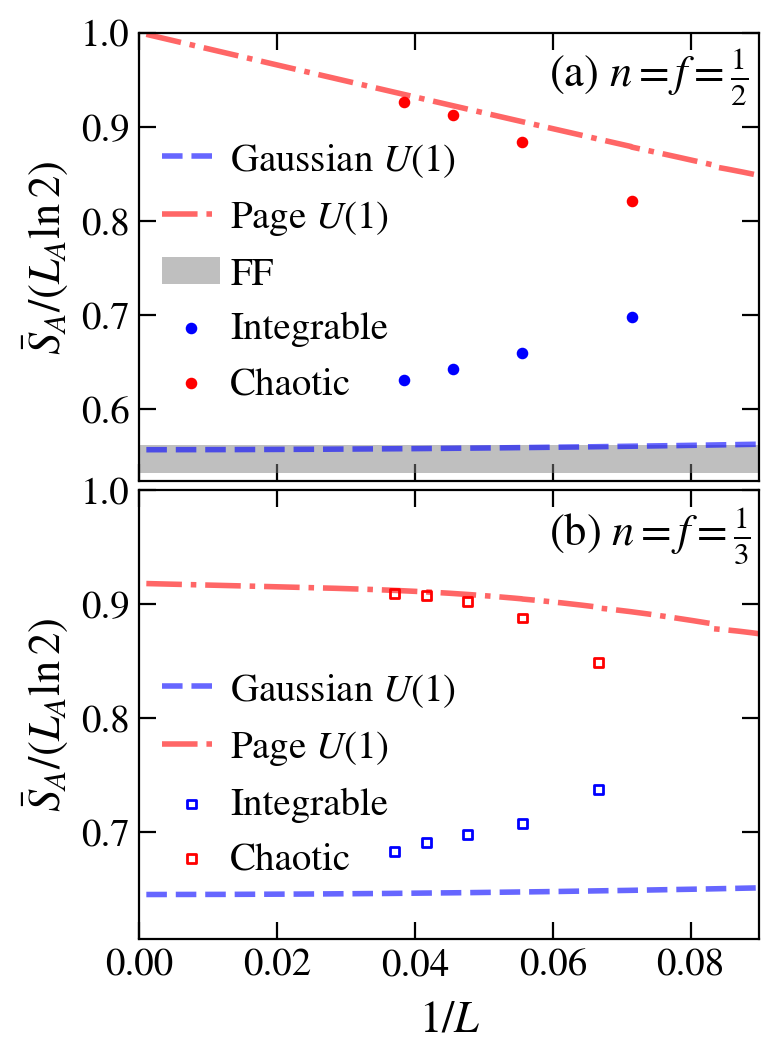

In [38]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,6), dpi = 200, sharex=True)

n = 1/2
for iin, n in enumerate([1/2, 1/3]):
    sizes = np.arange(14, 27, 4) if n == 1/2 else np.arange(15, 29, 3)


    Svn_int = np.zeros(sizes.shape)
    Svn_ch = np.zeros(sizes.shape)
    for iiL, L in enumerate(sizes):
        subsystem = np.arange(0, L, 1)
        N = int(L * n)
        LA = int(n * L)
        idx = np.argmin( np.abs(subsystem - LA) )
        if LA == L: idx = -1
        real_sec, imag_sec = get_sectors(L, BOUNDARY_COND, mu)
        
        dim_tot = 0
        dim_tot2 = 0
        for [ks, ps, zxs] in real_sec+imag_sec:
        # for [ks, ps, zxs] in imag_sec:
        # for [ks, ps, zxs] in real_sec:
            if ks == L / 4: print("Omitting k=\pi/2 sector"); continue;
        # for [ks, ps, zxs] in [[1, 1, 1]]:
            factor = 1 if ks == 0 or ks == L / 2 else 2
            # print(L, ks, ps, factor)
            V2 = 0
            t2 = 0
            name = base_dir + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=mu, k=ks, p=ps, zx=zxs) + ".hdf5"
            if exists(name):
                with h5py.File(name, "r") as file:
                    Ex = np.array(file.get('energies')[0])
                    _, indices, counts = np.unique(np.round(Ex, 14), return_index=True, return_counts=True)
                    x = counts[counts > 1]
                    if x.size > 0:
                        a=1
                        print(L, ks, ps)
                    else:
                        dim = Ex.size
                        print(L, dim)
                        Svn = np.array(file.get('entropy')[idx, :]) / (LA * np.log(2))
                        Svn_int[iiL] += dim * factor * np.mean(Svn[Svn.size//2-5 : Svn.size//2+5])
                        # Svn_int[iiL] += dim * factor * np.mean(Svn)
                        dim_tot += factor * dim                        
            else:
                print(name)
                
            V2 = 2
            t2 = 2
            name = base_dir + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=mu, k=ks, p=ps, zx=zxs) + ".hdf5"
            if exists(name):
                with h5py.File(name, "r") as file:
                    Ex = np.array(file.get('energies')[0])
                    _, indices, counts = np.unique(np.round(Ex, 14), return_index=True, return_counts=True)
                    x = counts[counts > 1]
                    if x.size > 0:
                        a=1
                        print(L, ks, ps)
                    else:
                        Svn = np.array(file.get('entropy')[idx, :]) / (LA * np.log(2))
                        Svn_ch[iiL] += dim * factor * np.mean(Svn[Svn.size//2-5 : Svn.size//2+5])
                        # Svn_ch[iiL] += dim * factor * np.mean(Svn)
                        dim_tot2 += factor * dim  
            else:
                print(name)
        Svn_ch[iiL] /= dim_tot2
        Svn_int[iiL] /= dim_tot
        # print(dim_tot, binom(L, N))
    axis[iin].scatter(1/sizes, Svn_int, s=10, label='Integrable', color='blue', marker='s' if iin else 'o', facecolor='None' if iin else 'blue')
    # axis.scatter(sizes, Purity_int_im, s=30, color = 'blue', marker='s', facecolor='None')

    p = axis[iin].scatter(1/sizes, Svn_ch, s=10, label='Chaotic', color='red', marker='s' if iin else 'o', facecolor='None' if iin else 'red')
    # axis.scatter(sizes, Purity_ch_im, s=30, color = 'red', marker='s', facecolor='None')

    z = np.linspace(1e-3, 0.1, 1000)
    Lz = 1/z
    yy = ent.gaussian_page_U1(Lz*n, Lz*(1-n), Lz*n) / (Lz*n * np.log(2))
    axis[iin].plot(z, yy, ls='--', color='blue', lw=2, alpha=0.6, label=r"Gaussian $U(1)$")
    axis[iin].plot(z, [ent.page_U1(Lx*n, Lx*(1-n), Lx*n) / (Lx*n * np.log(2)) for Lx in Lz], ls='-.', color='red', lw=2, alpha=0.6, label=r"Page $U(1)$")

    fig_help.set_plot_elements(axis[iin], ylabel=r"$\bar{S}_A/(L_A\ln{2})$", xlabel=r"$1/L$" if iin else "", font_size=14, set_legend=True, xlim=(0,0.09), ylim=(0.94 * min(yy[~np.isnan(yy)]), 1), xscale='linear', yscale='linear')

axis[0].axhspan(ymin = FF_lower_bound(f=1/2, x=1, n=4), ymax = FF_upper_bound(f=1/2, x=1, n=4), color='gray', lw=0, alpha=0.5, label=r"FF")

fig_help.set_legend(axis[0], fontsize=14, loc='lower left', ncol=1, anchor=(-0.02, 0.1))
fig_help.set_legend(axis[1], fontsize=14, loc='lower left', ncol=1, anchor=(-0.02, 0.06))

axis[0].annotate(r"(a) $n=f=\frac{1}{2}$", fontsize=16, xy=(0.66, 0.88), xycoords='axes fraction')
axis[1].annotate(r"(b) $n=f=\frac{1}{3}$", fontsize=16, xy=(0.66, 0.88), xycoords='axes fraction')

fig.subplots_adjust(wspace = 0.02, hspace=0.02)

fig.savefig("plots_mixing/Fig1.pdf", bbox_inches = 'tight', pad_inches=0.02)

In [ ]:
## CHECK V_1 = 1.1 for integrable case maybe it behaves better

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


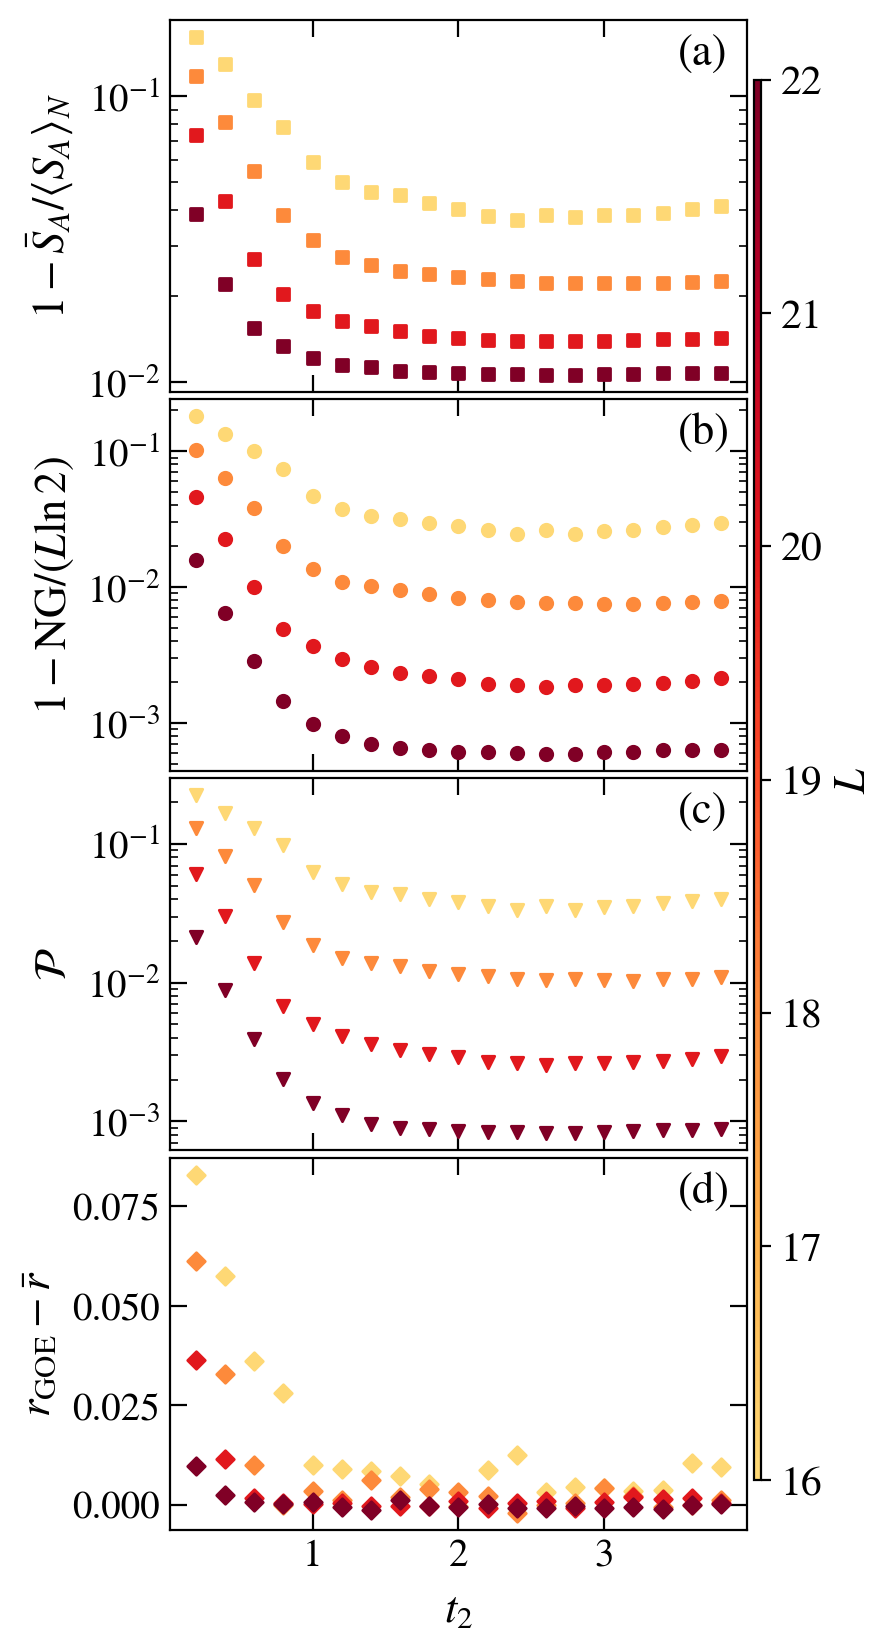

In [23]:
t1=1
t2=0
V1=0.55
V2=0.8
mu=1

fig, axis = plt.subplots( nrows=4, ncols=1, figsize=(3.5,10), dpi = 200, sharex=True)
axis = axis.flatten()

L = 20

sizes = np.arange(16, 23, 2)
norm = matplotlib.colors.Normalize(
                vmin=min(sizes),
                vmax=max(sizes) )


# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.25, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
# s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

for sth in range(0, 1):
    for iiL, L in enumerate(sizes):
        col = s_m.to_rgba(L) if sizes.size > 1 else 'k'
        
        N = L//2
        LA = L//2

        subsystem = np.arange(0, L, 1)
        idx = np.argmin( np.abs(subsystem - LA) )
        if LA == L: idx = -1
                
        t2_vals = np.arange(0.2, 4, 0.2)
        Svn = np.zeros(t2_vals.shape)
        NG = np.zeros(t2_vals.shape)
        P = np.zeros(t2_vals.shape)
        r = np.zeros(t2_vals.shape)
            
        for iit, t2 in enumerate(t2_vals):
            V2 = 0.55*t2 if sth else t2
            real_sec, imag_sec = get_sectors(L, BOUNDARY_COND, mu)
            
            dim_tot = 0
            for [ks, ps, zxs] in real_sec + imag_sec:
                name = base_dir + 'Entropy/Eigenstate/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=mu, k=ks, p=ps, zx=zxs) + ".hdf5"
                if exists(name):
                    with h5py.File(name, "r") as file:
                        Ex = np.array(file.get('energies')[0])
                        _, indices, counts = np.unique(np.round(Ex, 14), return_index=True, return_counts=True)
                        x = counts[counts > 1]
                        if x.size > 0:
                            a=1
                            print(L, ks, ps)
                        else:
                            Svn[iit] += dim * factor * np.mean(np.array(file.get('entropy')[idx, :])) / ent.page_U1(LA, L - LA, N)
                            NG[iit] += dim * factor * np.mean(np.array(file.get('Non-Gaussianity'))) / (L * np.log(2))
                            P[iit] += dim * factor * np.mean(np.array(file.get('Purity')[-1, :])) / L
                            dim_tot += factor * dim  
                            
                            gaps = np.diff(Ex)
                            ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
                            r[iit] +=  dim * factor * np.mean(ratio_tmp)
                else:
                    print(name)
            Svn[iit] /= dim_tot
            NG[iit] /= dim_tot
            P[iit] /= dim_tot
            r[iit] /= dim_tot
            
        axis[0].scatter(t2_vals, 1 - Svn,    s=20, color=col, facecolor = 'None' if sth else col, marker='s')
        axis[1].scatter(t2_vals, 1 - NG,     s=20, color=col, facecolor = 'None' if sth else col, marker='o')
        axis[2].scatter(t2_vals, P,          s=20, color=col, facecolor = 'None' if sth else col, marker='v')
        axis[3].scatter(t2_vals, 0.5307 - r, s=20, color=col, facecolor = 'None' if sth else col, marker='D')

fig_help.set_plot_elements(axis[0], ylabel=r"$1-\bar{S}_A/\langle S_A\rangle_N$", xlabel="", font_size=14, set_legend=True, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=r"$1-{\rm NG}/(L\ln{2})$", xlabel="", font_size=14, set_legend=True, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[2], ylabel=r"$\mathcal{P}$", xlabel=r"$t_2$", font_size=14, set_legend=True, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[3], ylabel=r"$r_{\rm GOE}-\bar{r}$", xlabel=r"$t_2$", font_size=14, set_legend=True, xscale='linear', yscale='linear')


axis[0].annotate(r"(a)", fontsize=16, xy=(0.88, 0.88), xycoords='axes fraction')
axis[1].annotate(r"(b)", fontsize=16, xy=(0.88, 0.88), xycoords='axes fraction')
axis[2].annotate(r"(c)", fontsize=16, xy=(0.88, 0.88), xycoords='axes fraction')
axis[3].annotate(r"(d)", fontsize=16, xy=(0.88, 0.88), xycoords='axes fraction')

fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.15, 0.01, 0.7])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1)
cbar.set_label(r"$L$", fontsize=16)
cbar.ax.tick_params(labelsize=15)

fig.subplots_adjust(wspace = 0.31, hspace=0.02)
fig.savefig("plots_mixing/FigA1.pdf", bbox_inches = 'tight', pad_inches=0.02)

In [61]:
L=12
N=6
t1=1
t2=0
V1=0.55
V2=0.0
mu=0

BOUNDARY_COND = 'ABC'

name = "../results/" + BOUNDARY_COND + '/' + 'Purity/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
if exists(name):
    with h5py.File(name, "r") as file:
        Ex = np.array(file.get('energies')[0])
        _, indices, counts = np.unique(np.round(Ex, 14), return_index=True, return_counts=True)
        x = counts[counts > 1]
        print(x)
        gaps = np.diff(Ex)
        ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
        
        print(t1, t2, V1, V2, np.mean(ratio_tmp))
else:
    print(name)
    
t1=1
t2=2
V1=0.55
V2=2.0
mu=0

BOUNDARY_COND = 'ABC'

name = "../results/" + BOUNDARY_COND + '/' + 'Purity/' + info(L=L, N = N, t1=t1, V1=V1, t2=t2, V2=V2, mu=1, k=1, BOUNDARY_COND=BOUNDARY_COND) + ".hdf5"
if exists(name):
    with h5py.File(name, "r") as file:
        Ex = np.array(file.get('energies')[0])
        _, indices, counts = np.unique(np.round(Ex, 14), return_index=True, return_counts=True)
        x = counts[counts > 1]
        print(x)
        gaps = np.diff(Ex)
        ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
        
        print(t1, t2, V1, V2, np.mean(ratio_tmp))
else:
    print(name)

[]
1 0 0.55 0.0 0.393123779288074
[]
1 2 0.55 2.0 0.5211244751984949
